# AWID 2026 - PyTorch Reference Benchmark

PyTorch baseline for the same FashionMNIST CNN architecture used in the Julia notebooks.

## Cell 1 - Imports, data and model definition

In [1]:
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

random.seed(42)
np.random.seed(42)

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
torch.manual_seed(42)

transform = transforms.ToTensor()
train_data = datasets.FashionMNIST(root='.data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='.data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=10, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=1024, shuffle=False, num_workers=0)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=3, padding=1, bias=False),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(6, 16, kernel_size=3, padding=1, bias=False),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(784, 84),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(84, 10),
        )

    def forward(self, x):
        return self.net(x)

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
print(model)

100.0%
100.0%
100.0%
100.0%

CNN(
  (net): Sequential(
    (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=784, out_features=84, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=84, out_features=10, bias=True)
  )
)


## Cell 2 - Training and evaluation helpers

In [2]:
def accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item() * 100.0

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_batches = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item()
            total_acc += accuracy(logits, y)
            total_batches += 1
    return total_loss / total_batches, total_acc / total_batches

history = []
epochs = 3


## Cell 3 - Training loop

In [3]:
for epoch in range(1, epochs + 1):
    model.train()
    start = time.perf_counter()
    running_loss = 0.0
    running_acc = 0.0
    batches = 0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_acc += accuracy(logits, y)
        batches += 1
    train_time = time.perf_counter() - start
    train_loss = running_loss / batches
    train_acc = running_acc / batches
    test_loss, test_acc = evaluate(model, test_loader)
    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'train_time_s': train_time,
    })
    print(f'epoch={epoch} train_loss={train_loss:.4f} train_acc={train_acc:.2f} test_loss={test_loss:.4f} test_acc={test_acc:.2f} time={train_time:.2f}s')

epoch=1 train_loss=0.7592 train_acc=71.31 test_loss=0.4837 test_acc=82.36 time=12.47s
epoch=2 train_loss=0.4942 train_acc=82.20 test_loss=0.4367 test_acc=83.90 time=13.40s
epoch=3 train_loss=0.4339 train_acc=84.53 test_loss=0.3718 test_acc=86.44 time=12.72s


## Cell 4 - Accuracy plot and final evaluation

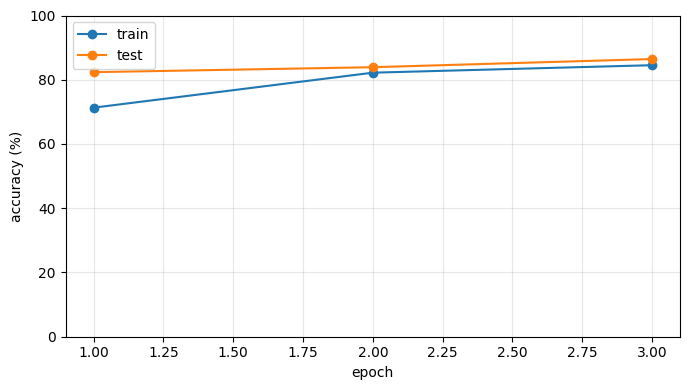

{'final_test_loss': 0.37175306379795076, 'final_test_acc': 86.4447146654129}


In [4]:
epochs_axis = [item['epoch'] for item in history]
train_accs = [item['train_acc'] for item in history]
test_accs = [item['test_acc'] for item in history]

plt.figure(figsize=(7, 4))
plt.plot(epochs_axis, train_accs, marker='o', label='train')
plt.plot(epochs_axis, test_accs, marker='o', label='test')
plt.xlabel('epoch')
plt.ylabel('accuracy (%)')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

final_test_loss, final_test_acc = evaluate(model, test_loader)
print({'final_test_loss': final_test_loss, 'final_test_acc': final_test_acc})

## Cell 5 - Sample image visualization

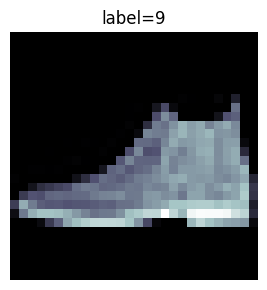

In [5]:
x, y = next(iter(test_loader))
plt.figure(figsize=(3, 3))
plt.imshow(x[0, 0], cmap='bone')
plt.title(f'label={y[0].item()}')
plt.axis('off')
plt.tight_layout()
plt.show()